In [1]:
import pandas as pd

In [4]:
import pandas as pd

df = pd.read_csv("/Internship.csv")

df

,Name,DOB,Date of Joining,Gender,Internship Salary
0,Abhishek,24-01-1998,24-01-2022,M,13000
1,Nayan,10-10-1998,10-10-2022,M,17000
2,Yashasvi,18-12-1998,18-12-2022,F,21000
3,Anurag,08-04-1999,08-04-2023,M,16000
4,Smriti,04-08-1999,04-08-2023,F,18000
5,Sonia,22-09-1998,22-09-2022,F,21000
6,Rahul,28-02-2000,15-09-2022,M,22500
7,Amit,01-06-1999,01-06-2023,M,19000
8,Hari,13-09-1999,13-09-2023,M,23000
9,Ravi,25-02-1999,25-02-2023,M,26000


In [5]:
df.shape

(15, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               15 non-null     object
 1   DOB                15 non-null     object
 2   Date of Joining    15 non-null     object
 3   Gender             15 non-null     object
 4   Internship Salary  15 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 732.0+ bytes


In [7]:
df['DOB'] = pd.to_datetime(df['DOB'], format='%d-%m-%Y')
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'], format='%d-%m-%Y')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               15 non-null     object        
 1   DOB                15 non-null     datetime64[ns]
 2   Date of Joining    15 non-null     datetime64[ns]
 3   Gender             15 non-null     object        
 4   Internship Salary  15 non-null     int64         
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 732.0+ bytes


In [9]:
df['Age'] = (
    df['Date of Joining'] - df['DOB']
).dt.days / 365.25

df['Age'] = df['Age'].round(1)

In [10]:
df[['Name', 'DOB', 'Date of Joining', 'Age']]

,Name,DOB,Date of Joining,Age
0,Abhishek,1998-01-24,2022-01-24,24.0
1,Nayan,1998-10-10,2022-10-10,24.0
2,Yashasvi,1998-12-18,2022-12-18,24.0
3,Anurag,1999-04-08,2023-04-08,24.0
4,Smriti,1999-08-04,2023-08-04,24.0
5,Sonia,1998-09-22,2022-09-22,24.0
6,Rahul,2000-02-28,2022-09-15,22.5
7,Amit,1999-06-01,2023-06-01,24.0
8,Hari,1999-09-13,2023-09-13,24.0
9,Ravi,1999-02-25,2023-02-25,24.0


In [11]:
df['Joining Year'] = df['Date of Joining'].dt.year

In [12]:
df[['Name', 'Date of Joining', 'Joining Year']]

,Name,Date of Joining,Joining Year
0,Abhishek,2022-01-24,2022
1,Nayan,2022-10-10,2022
2,Yashasvi,2022-12-18,2022
3,Anurag,2023-04-08,2023
4,Smriti,2023-08-04,2023
5,Sonia,2022-09-22,2022
6,Rahul,2022-09-15,2022
7,Amit,2023-06-01,2023
8,Hari,2023-09-13,2023
9,Ravi,2023-02-25,2023


In [13]:
df['Gender'].value_counts()


,count
Gender,
M,10
F,5


In [14]:
df['Gender'].value_counts(normalize=True) * 100

,proportion
Gender,
M,66.666667
F,33.333333


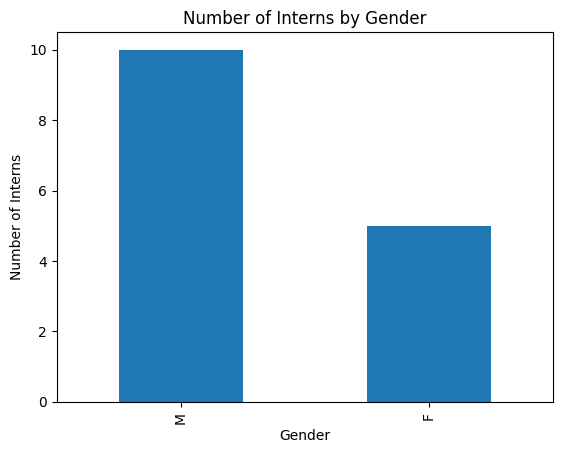

In [16]:
import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(kind='bar')

plt.title('Number of Interns by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Interns')
plt.show()

In [17]:
print("Average Salary:", df['Internship Salary'].mean())
print("Highest Salary:", df['Internship Salary'].max())
print("Lowest Salary:", df['Internship Salary'].min())
print("Median Salary:", df['Internship Salary'].median())

Average Salary: 21366.666666666668
Highest Salary: 31000
Lowest Salary: 13000
Median Salary: 21000.0


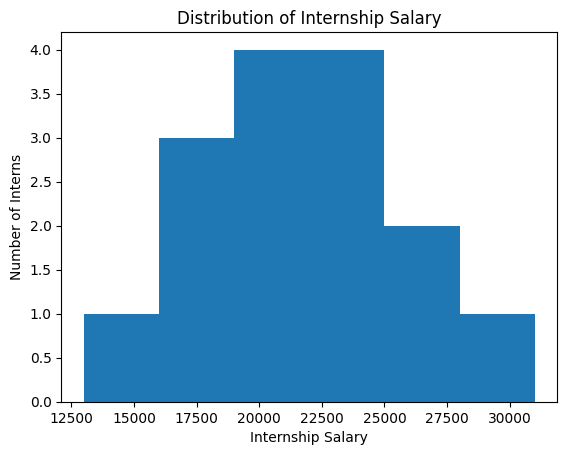

In [18]:
import matplotlib.pyplot as plt

plt.hist(df['Internship Salary'], bins=6)

plt.title('Distribution of Internship Salary')
plt.xlabel('Internship Salary')
plt.ylabel('Number of Interns')

plt.show()

In [19]:
df.groupby('Gender')['Internship Salary'].mean()

,Internship Salary
Gender,
F,23000.0
M,20550.0


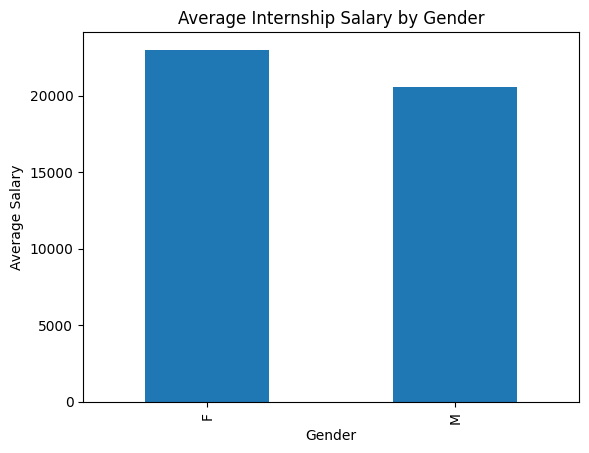

In [20]:
df.groupby('Gender')['Internship Salary'].mean().plot(kind='bar')

plt.title('Average Internship Salary by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Salary')

plt.show()

In [21]:
df.groupby('Joining Year')['Internship Salary'].mean()

,Internship Salary
Joining Year,
2022,21687.5
2023,21000.0


In [22]:
df['Joining Year'].value_counts().sort_index()

,count
Joining Year,
2022,8
2023,7


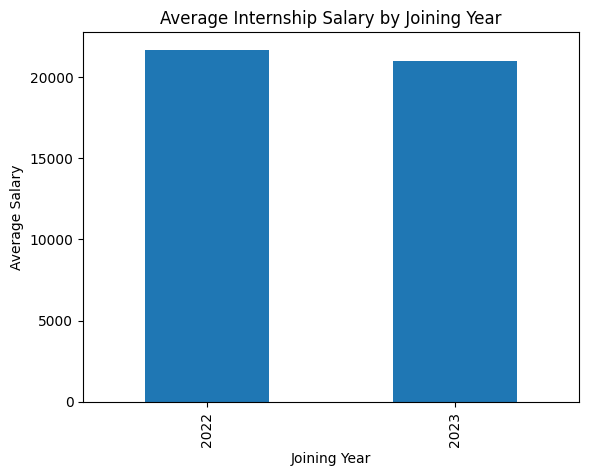

In [23]:
df.groupby('Joining Year')['Internship Salary'].mean().plot(kind='bar')

plt.title('Average Internship Salary by Joining Year')
plt.xlabel('Joining Year')
plt.ylabel('Average Salary')

plt.show()

In [24]:
df['Age'].min()

22.2

In [25]:
df['Age'].max()

24.0

In [26]:
df['Age'].mean()

np.float64(23.59333333333333)

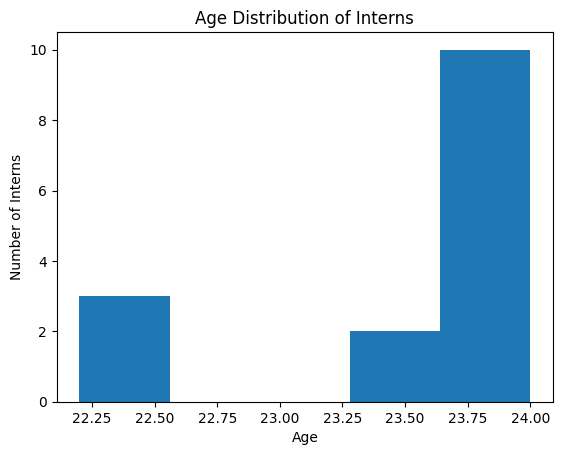

In [27]:
plt.hist(df['Age'], bins=5)

plt.title('Age Distribution of Interns')
plt.xlabel('Age')
plt.ylabel('Number of Interns')

plt.show()

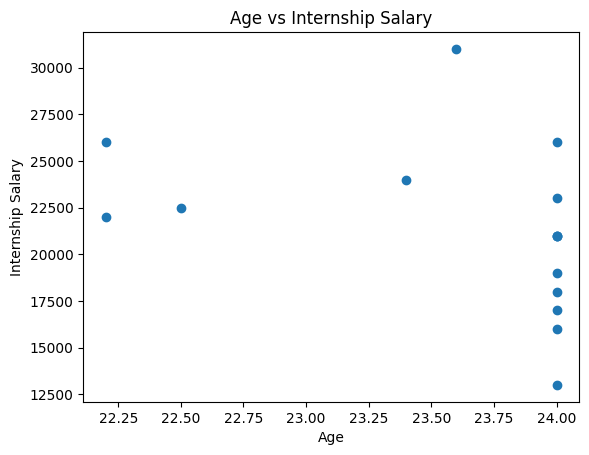

In [29]:
plt.scatter(df['Age'], df['Internship Salary'])

plt.title('Age vs Internship Salary')
plt.xlabel('Age')
plt.ylabel('Internship Salary')

plt.show()

In [30]:
df['Age'].corr(df['Internship Salary'])

np.float64(-0.38008407741215977)

In [31]:
df.loc[df['Internship Salary'].idxmax()]

,14
Name,Sowmya
DOB,1999-02-26 00:00:00
Date of Joining,2022-10-15 00:00:00
Gender,F
Internship Salary,31000
Age,23.6
Joining Year,2022


In [32]:
df.loc[df['Internship Salary'].idxmin()]

,0
Name,Abhishek
DOB,1998-01-24 00:00:00
Date of Joining,2022-01-24 00:00:00
Gender,M
Internship Salary,13000
Age,24.0
Joining Year,2022


In [33]:
df[['Name', 'Gender', 'Age', 'Joining Year', 'Internship Salary']].sort_values(
    by='Internship Salary',
    ascending=False
)

,Name,Gender,Age,Joining Year,Internship Salary
14,Sowmya,F,23.6,2022,31000
9,Ravi,M,24.0,2023,26000
12,Naveen,M,22.2,2022,26000
13,Sreya,F,23.4,2023,24000
8,Hari,M,24.0,2023,23000
6,Rahul,M,22.5,2022,22500
11,John,M,22.2,2022,22000
2,Yashasvi,F,24.0,2022,21000
5,Sonia,F,24.0,2022,21000
10,Pranay,M,24.0,2023,21000


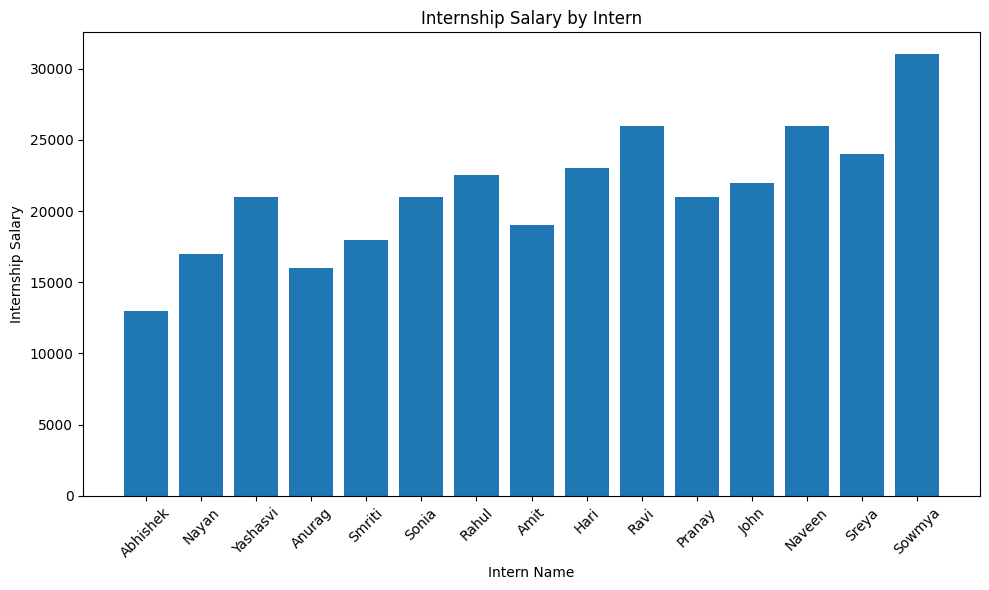

In [34]:
plt.figure(figsize=(10, 6))

plt.bar(df['Name'], df['Internship Salary'])

plt.title('Internship Salary by Intern')
plt.xlabel('Intern Name')
plt.ylabel('Internship Salary')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

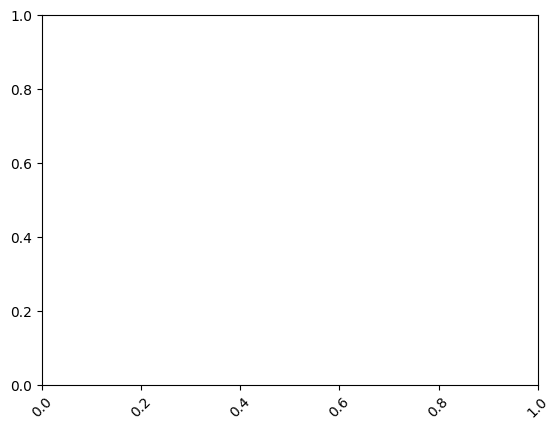

In [35]:
plt.xticks(rotation=45)

In [36]:
print(df.shape)
print(df['Name'].tolist())

(15, 7)
['Abhishek', 'Nayan', 'Yashasvi', 'Anurag', 'Smriti', 'Sonia', 'Rahul', 'Amit', 'Hari', 'Ravi', 'Pranay', 'John', 'Naveen', 'Sreya', 'Sowmya']


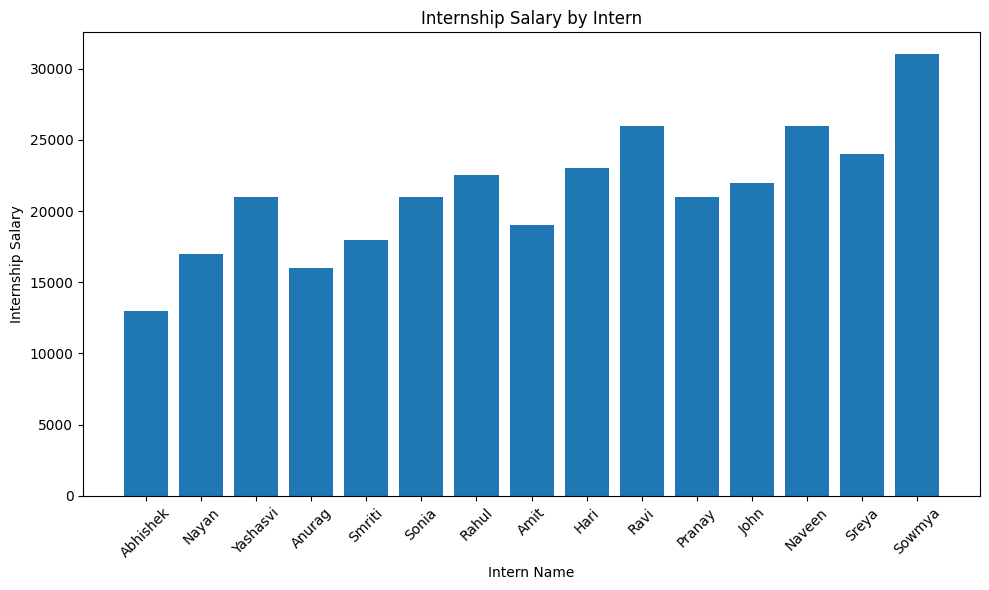

In [37]:
plt.figure(figsize=(10, 6))

plt.bar(
    df['Name'],
    df['Internship Salary']
)

plt.title('Internship Salary by Intern')
plt.xlabel('Intern Name')
plt.ylabel('Internship Salary')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
df['Internship Salary'].std()

4489.935835791399

In [39]:
df['Internship Salary'].describe()

,Internship Salary
count,15.000000
mean,21366.666667
std,4489.935836
min,13000.000000
25%,18500.000000
50%,21000.000000
75%,23500.000000
max,31000.000000


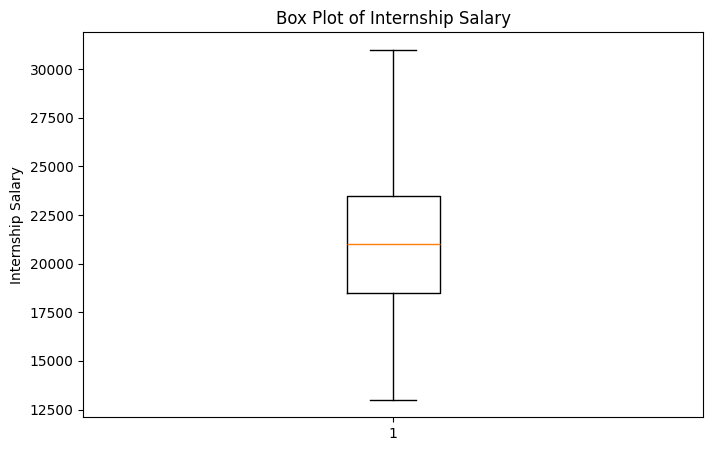

In [40]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['Internship Salary'])

plt.title('Box Plot of Internship Salary')
plt.ylabel('Internship Salary')

plt.show()

In [41]:
df.groupby(['Joining Year', 'Gender'])['Internship Salary'].mean()

Joining Year  Gender
2022          F         24333.333333
              M         20100.000000
2023          F         21000.000000
              M         21000.000000
Name: Internship Salary, dtype: float64

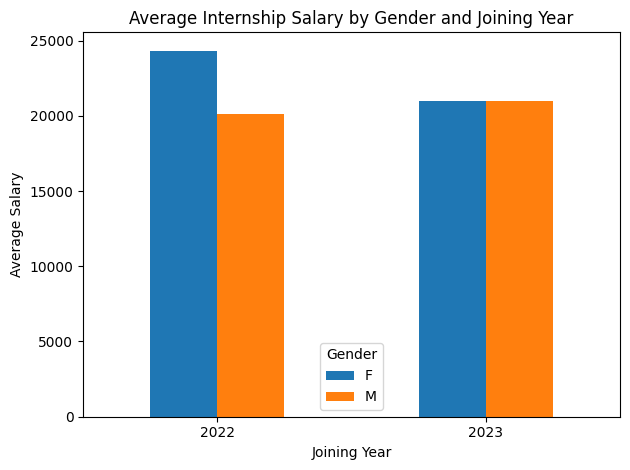

In [42]:
salary_gender_year = df.groupby(
    ['Joining Year', 'Gender']
)['Internship Salary'].mean().unstack()

salary_gender_year.plot(kind='bar')

plt.title('Average Internship Salary by Gender and Joining Year')
plt.xlabel('Joining Year')
plt.ylabel('Average Salary')
plt.xticks(rotation=0)

plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [43]:
df[['Age', 'Joining Year', 'Internship Salary']].corr()

,Age,Joining Year,Internship Salary
Age,1.000000,0.446907,-0.380084
Joining Year,0.446907,1.000000,-0.079071
Internship Salary,-0.380084,-0.079071,1.000000


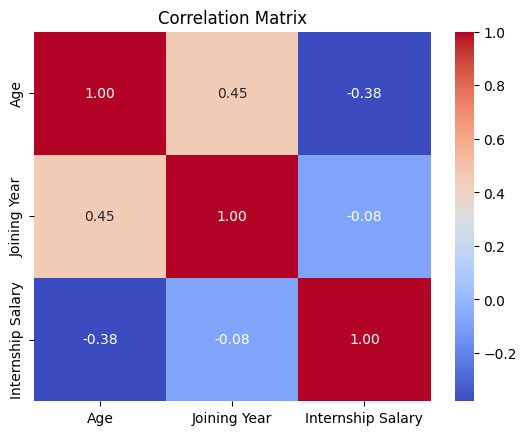

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[['Age', 'Joining Year', 'Internship Salary']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [45]:
df[['Name', 'Age', 'Gender', 'Joining Year', 'Internship Salary']]

,Name,Age,Gender,Joining Year,Internship Salary
0,Abhishek,24.0,M,2022,13000
1,Nayan,24.0,M,2022,17000
2,Yashasvi,24.0,F,2022,21000
3,Anurag,24.0,M,2023,16000
4,Smriti,24.0,F,2023,18000
5,Sonia,24.0,F,2022,21000
6,Rahul,22.5,M,2022,22500
7,Amit,24.0,M,2023,19000
8,Hari,24.0,M,2023,23000
9,Ravi,24.0,M,2023,26000


In [46]:
X = df[['Age', 'Gender', 'Joining Year']]
y = df['Internship Salary']

In [47]:
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

In [48]:
X

,Age,Joining Year,Gender_M
0,24.0,2022,True
1,24.0,2022,True
2,24.0,2022,False
3,24.0,2023,True
4,24.0,2023,False
5,24.0,2022,False
6,22.5,2022,True
7,24.0,2023,True
8,24.0,2023,True
9,24.0,2023,True


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 3)
Testing data: (3, 3)


In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model = LinearRegression()

In [53]:
model.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred = model.predict(X_test)

print("Actual Salaries:")
print(y_test.values)

print("\nPredicted Salaries:")
print(y_pred)

Actual Salaries:
[26000 22000 13000]

Predicted Salaries:
[18721.71729251 25733.73594834 19229.66993542]


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5747.229530415342
MSE: 35240990.268768676
RMSE: 5936.41223878267
R2 Score: -0.19236433240194795


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Actual Salaries:")
print(y_test.values)

print("\nRandom Forest Predictions:")
print(rf_pred)

Actual Salaries:
[26000 22000 13000]

Random Forest Predictions:
[19903.         25055.         18499.47619048]


In [57]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)


Random Forest MAE: 4883.825396825396
Random Forest MSE: 25583557.456538156
Random Forest RMSE: 5058.01912378138
Random Forest R2 Score: 0.1343909131246488


In [58]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'MSE': [mse, rf_mse],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5747.229530,3.524099e+07,5936.412239,-0.192364
1,Random Forest,4883.825397,2.558356e+07,5058.019124,0.134391


In [59]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Age,0.789946
2,Gender_M,0.116836
1,Joining Year,0.093218


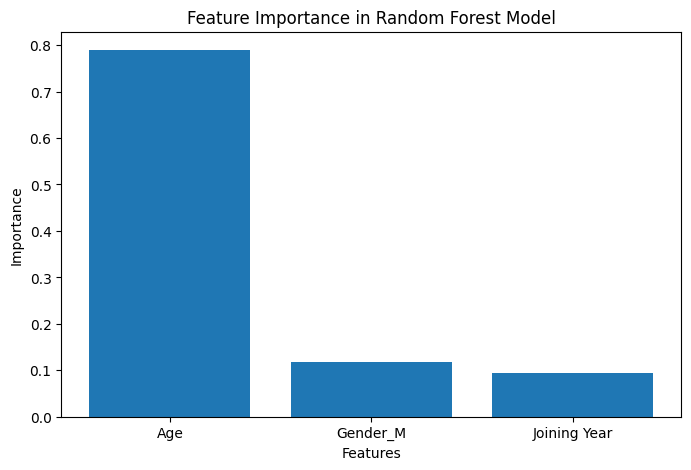

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(importance['Feature'], importance['Importance'])

plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.show()

In [61]:
github_df = df.copy()

github_df = github_df.drop(columns=['Name', 'DOB', 'Date of Joining'])

github_df.to_csv('Internship_Salary_Analysis_Data.csv', index=False)

github_df

,Gender,Internship Salary,Age,Joining Year
0,M,13000,24.0,2022
1,M,17000,24.0,2022
2,F,21000,24.0,2022
3,M,16000,24.0,2023
4,F,18000,24.0,2023
5,F,21000,24.0,2022
6,M,22500,22.5,2022
7,M,19000,24.0,2023
8,M,23000,24.0,2023
9,M,26000,24.0,2023
